In [12]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
def transformar_df(df): 
    return (
        df.select(
            pl.col(['year', 'value'])
        )
        .rename({
            'year': 'ano',
            'value': 'valor'
        })
        .with_columns(
            pl.col('ano').cast(pl.Int64),
            pl.col('valor').cast(pl.Float64)
        )
    )   

In [14]:
df_hdi = transformar_df(pl.read_excel('hdi_un.xlsx'))

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 11, falling back to string


In [15]:
df_hdi.head()

ano,valor
i64,f64
1990,0.641
1991,0.645
1992,0.648
1993,0.654
1994,0.659


In [16]:
def gerar_grafico_linha(df, indice):
    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df,
        x='ano',
        y='valor',
        marker='o',
        errorbar=None
    )

    anos = sorted(df['ano'].unique().to_list())

    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.set_ylabel('Valor', fontweight='bold')
    ax.set_xlabel('Ano', fontweight='bold')

    fig.savefig(f'onu_{indice}_brasil', dpi=300, bbox_inches='tight')
    plt.show()

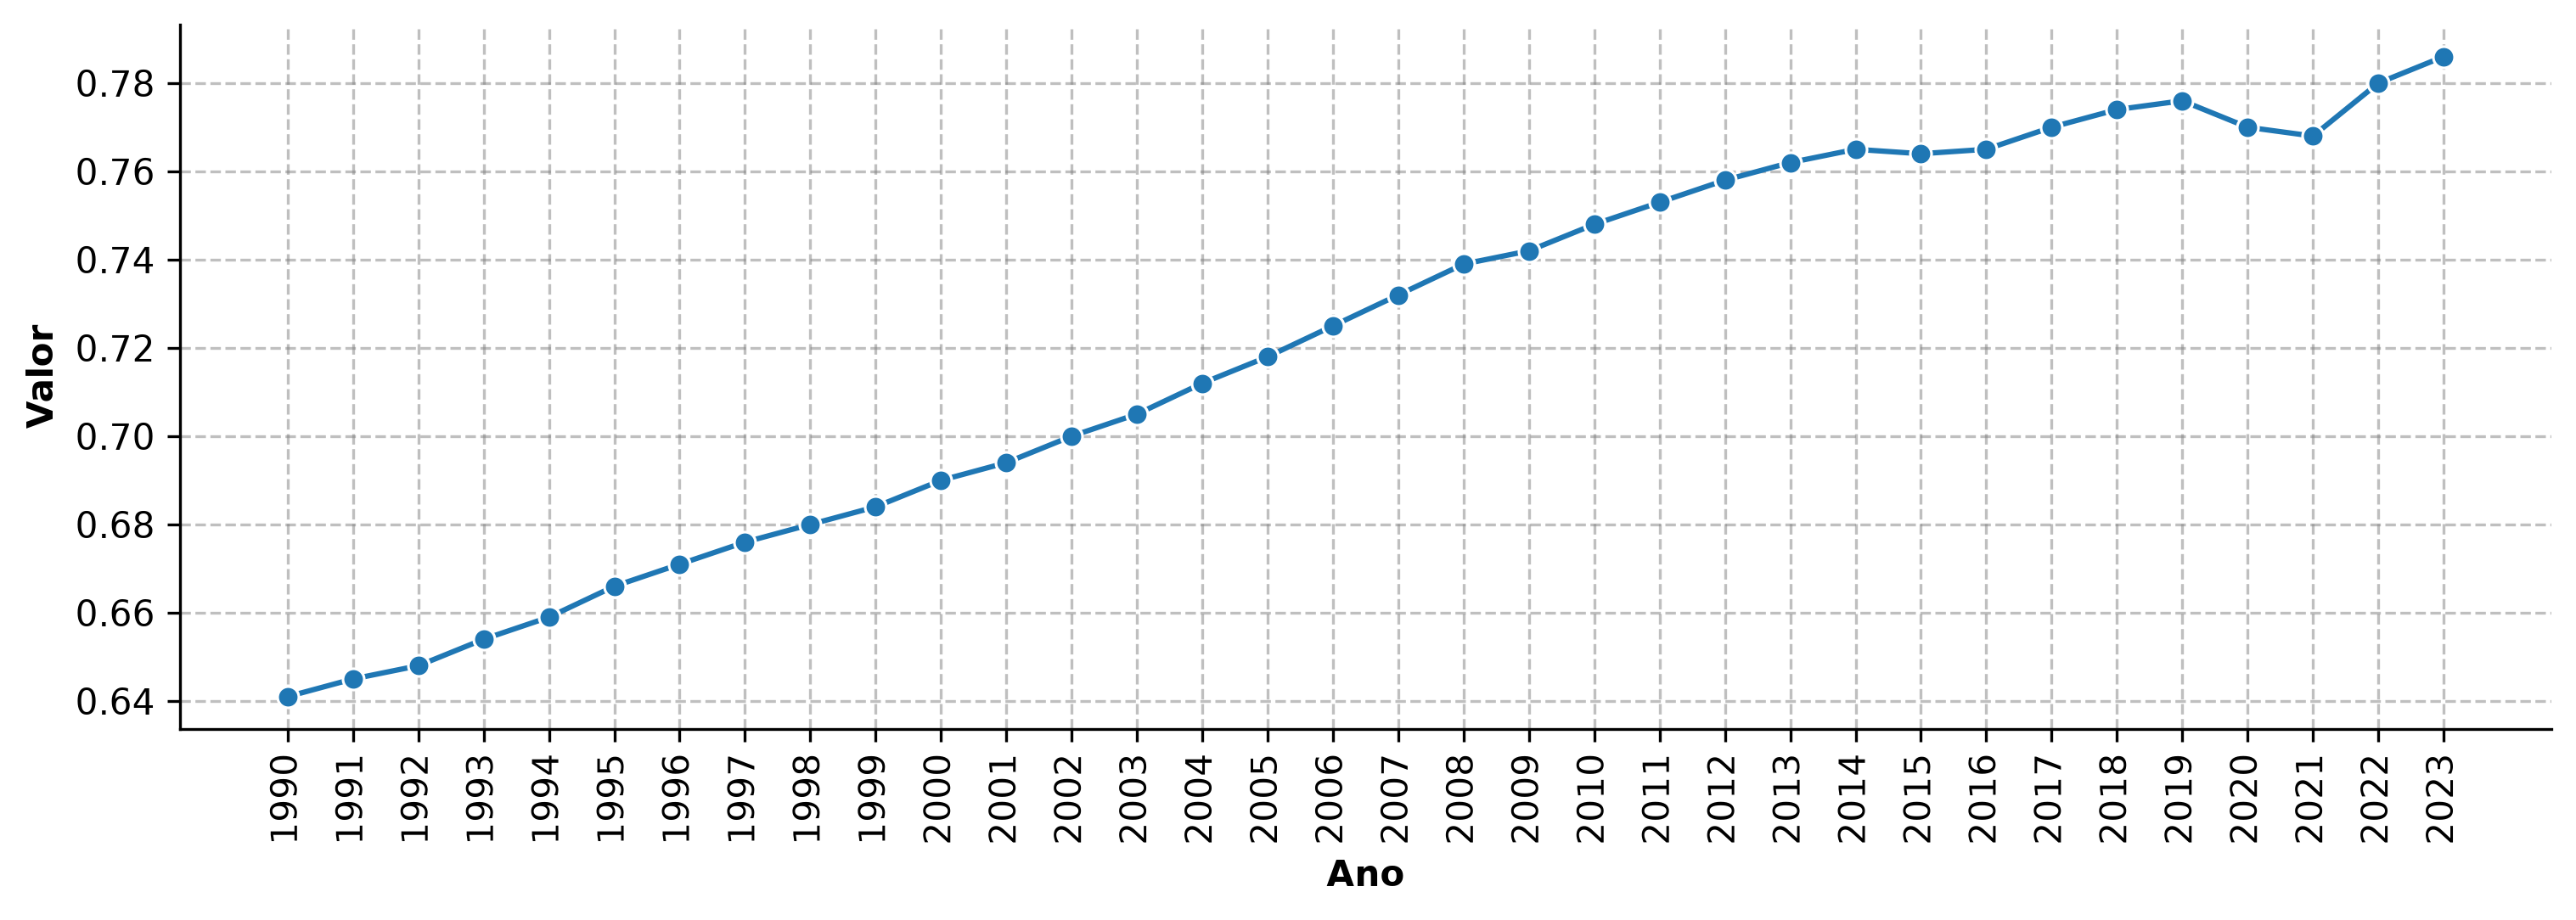

In [17]:
gerar_grafico_linha(df_hdi, 'idh')

In [18]:
df_gii = transformar_df(pl.read_excel('gii_un.xlsx'))

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 11, falling back to string


In [19]:
df_gii.head()

ano,valor
i64,f64
1990,0.582
1991,0.577
1992,0.561
1993,0.557
1994,0.553


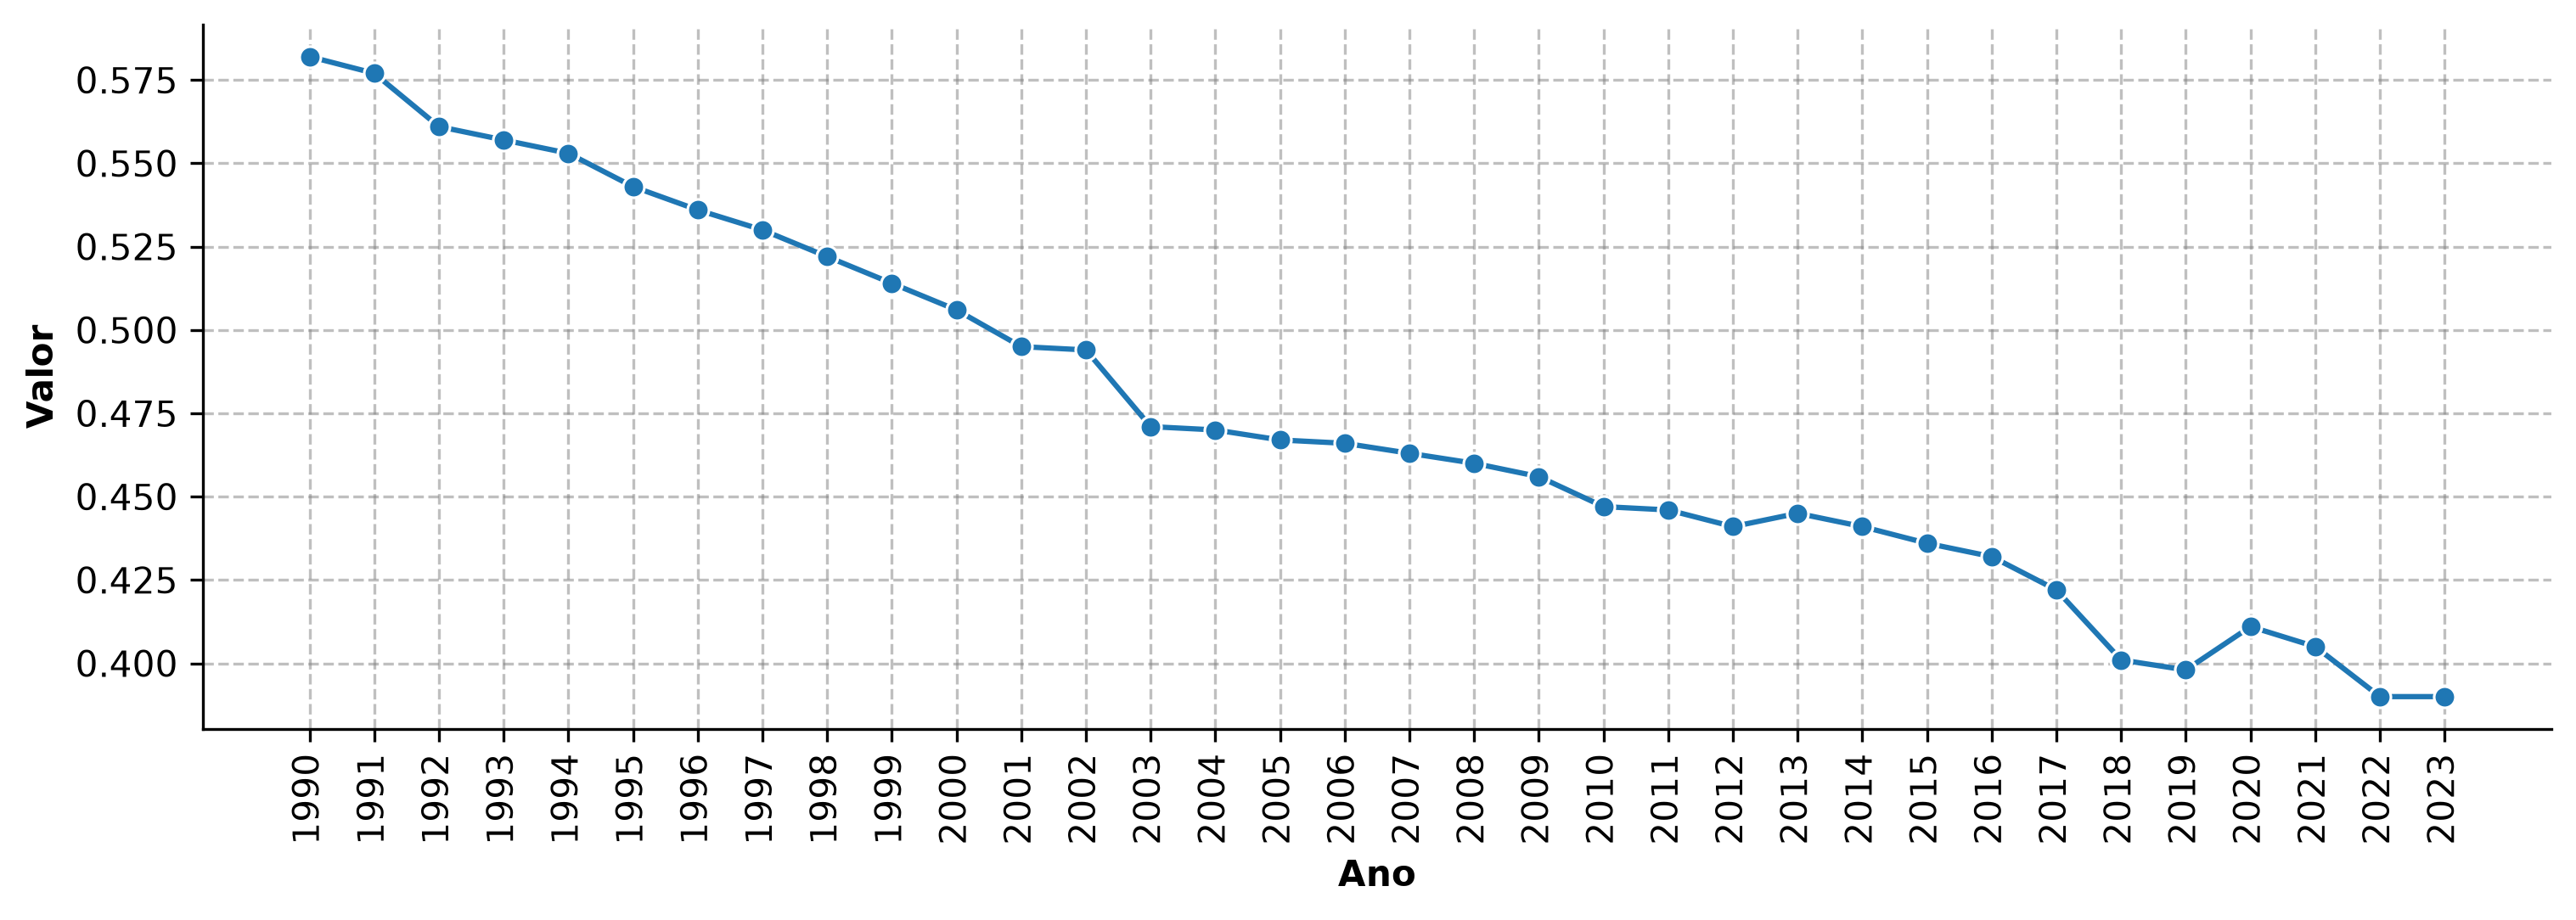

In [20]:
gerar_grafico_linha(df_gii, 'gii')

In [21]:
df_gdi = transformar_df(pl.read_excel('gdi_un.xlsx'))

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 11, falling back to string


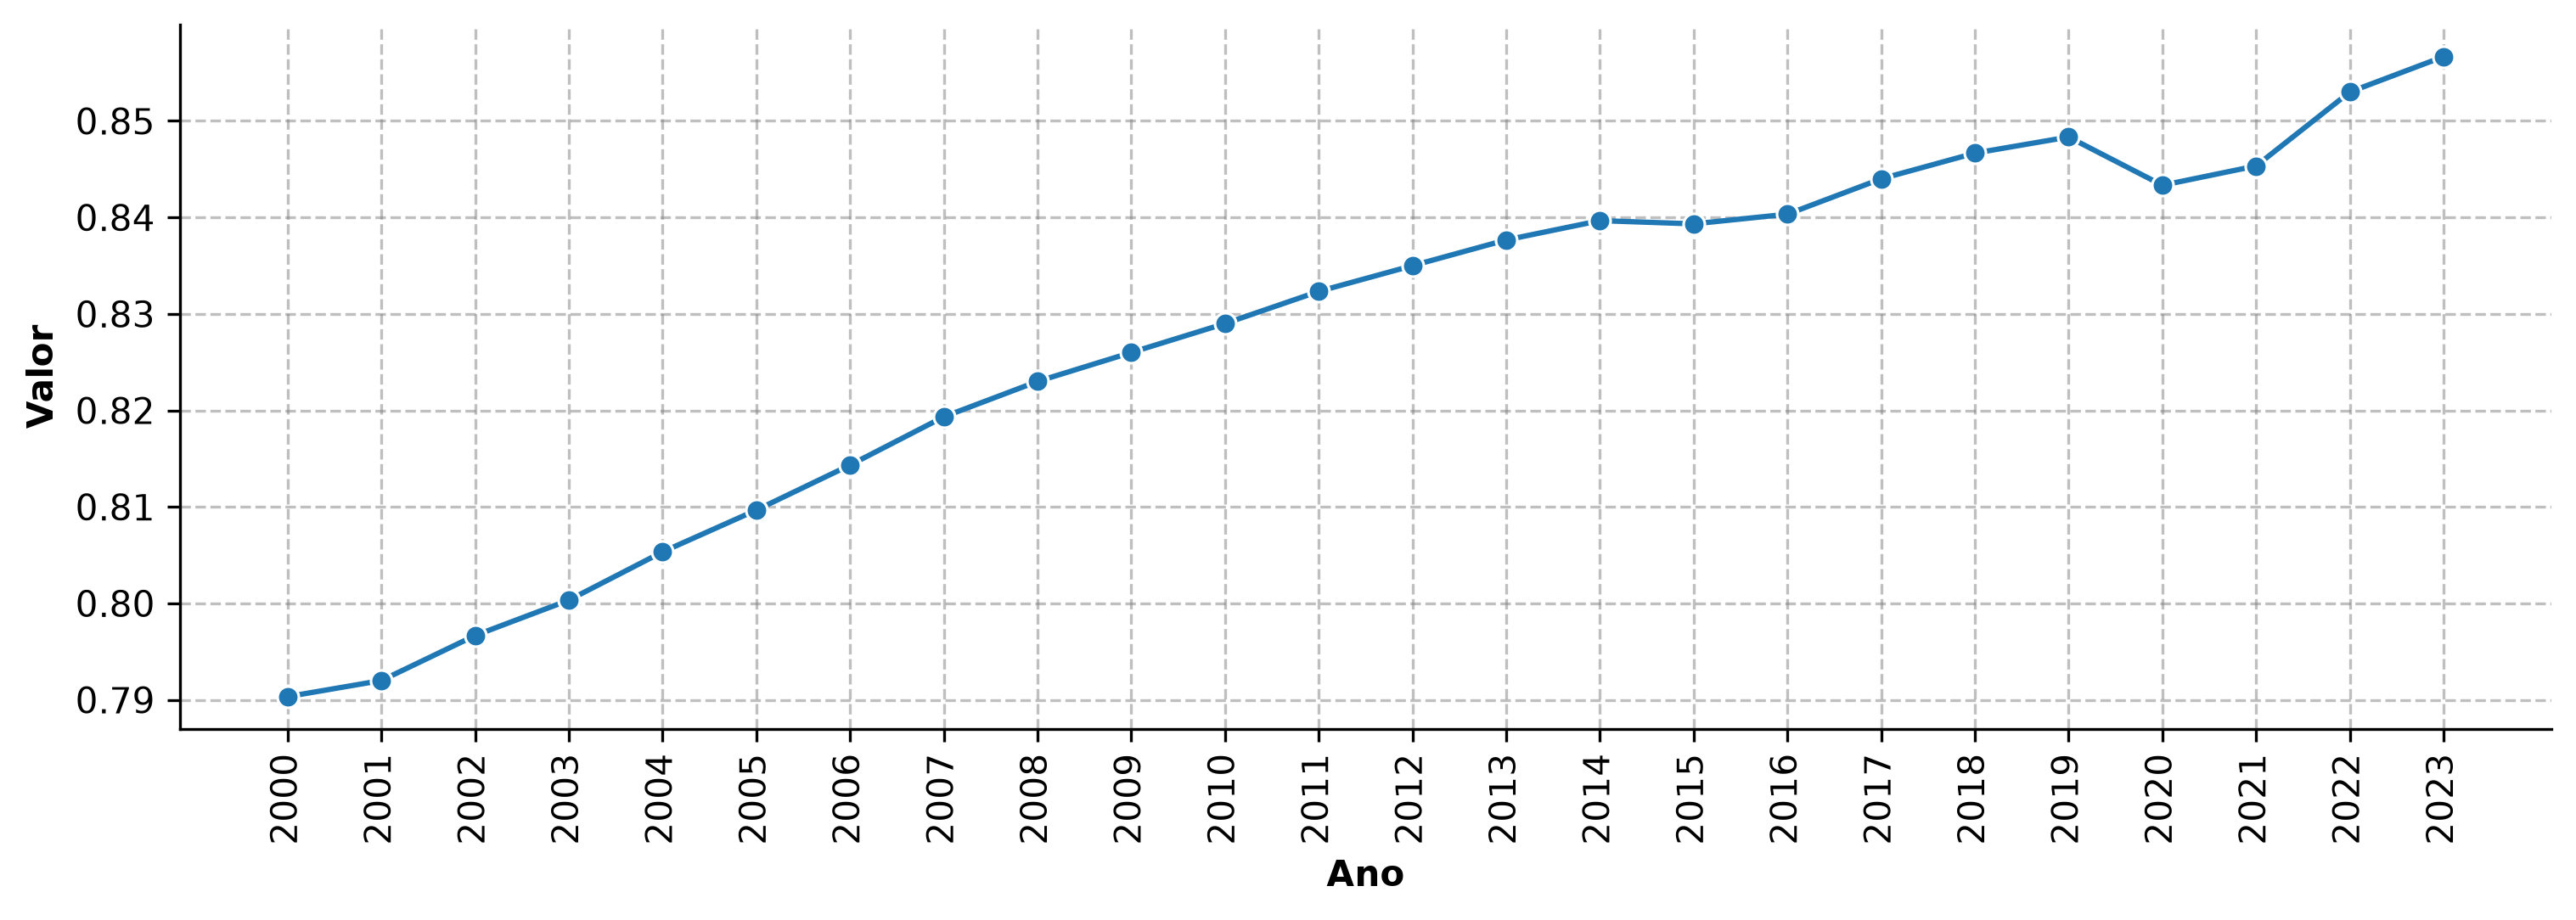

In [22]:
gerar_grafico_linha(df_gdi, 'gdi')

In [23]:
df_ihdi = transformar_df(pl.read_excel('ihdi_un.xlsx'))

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 11, falling back to string


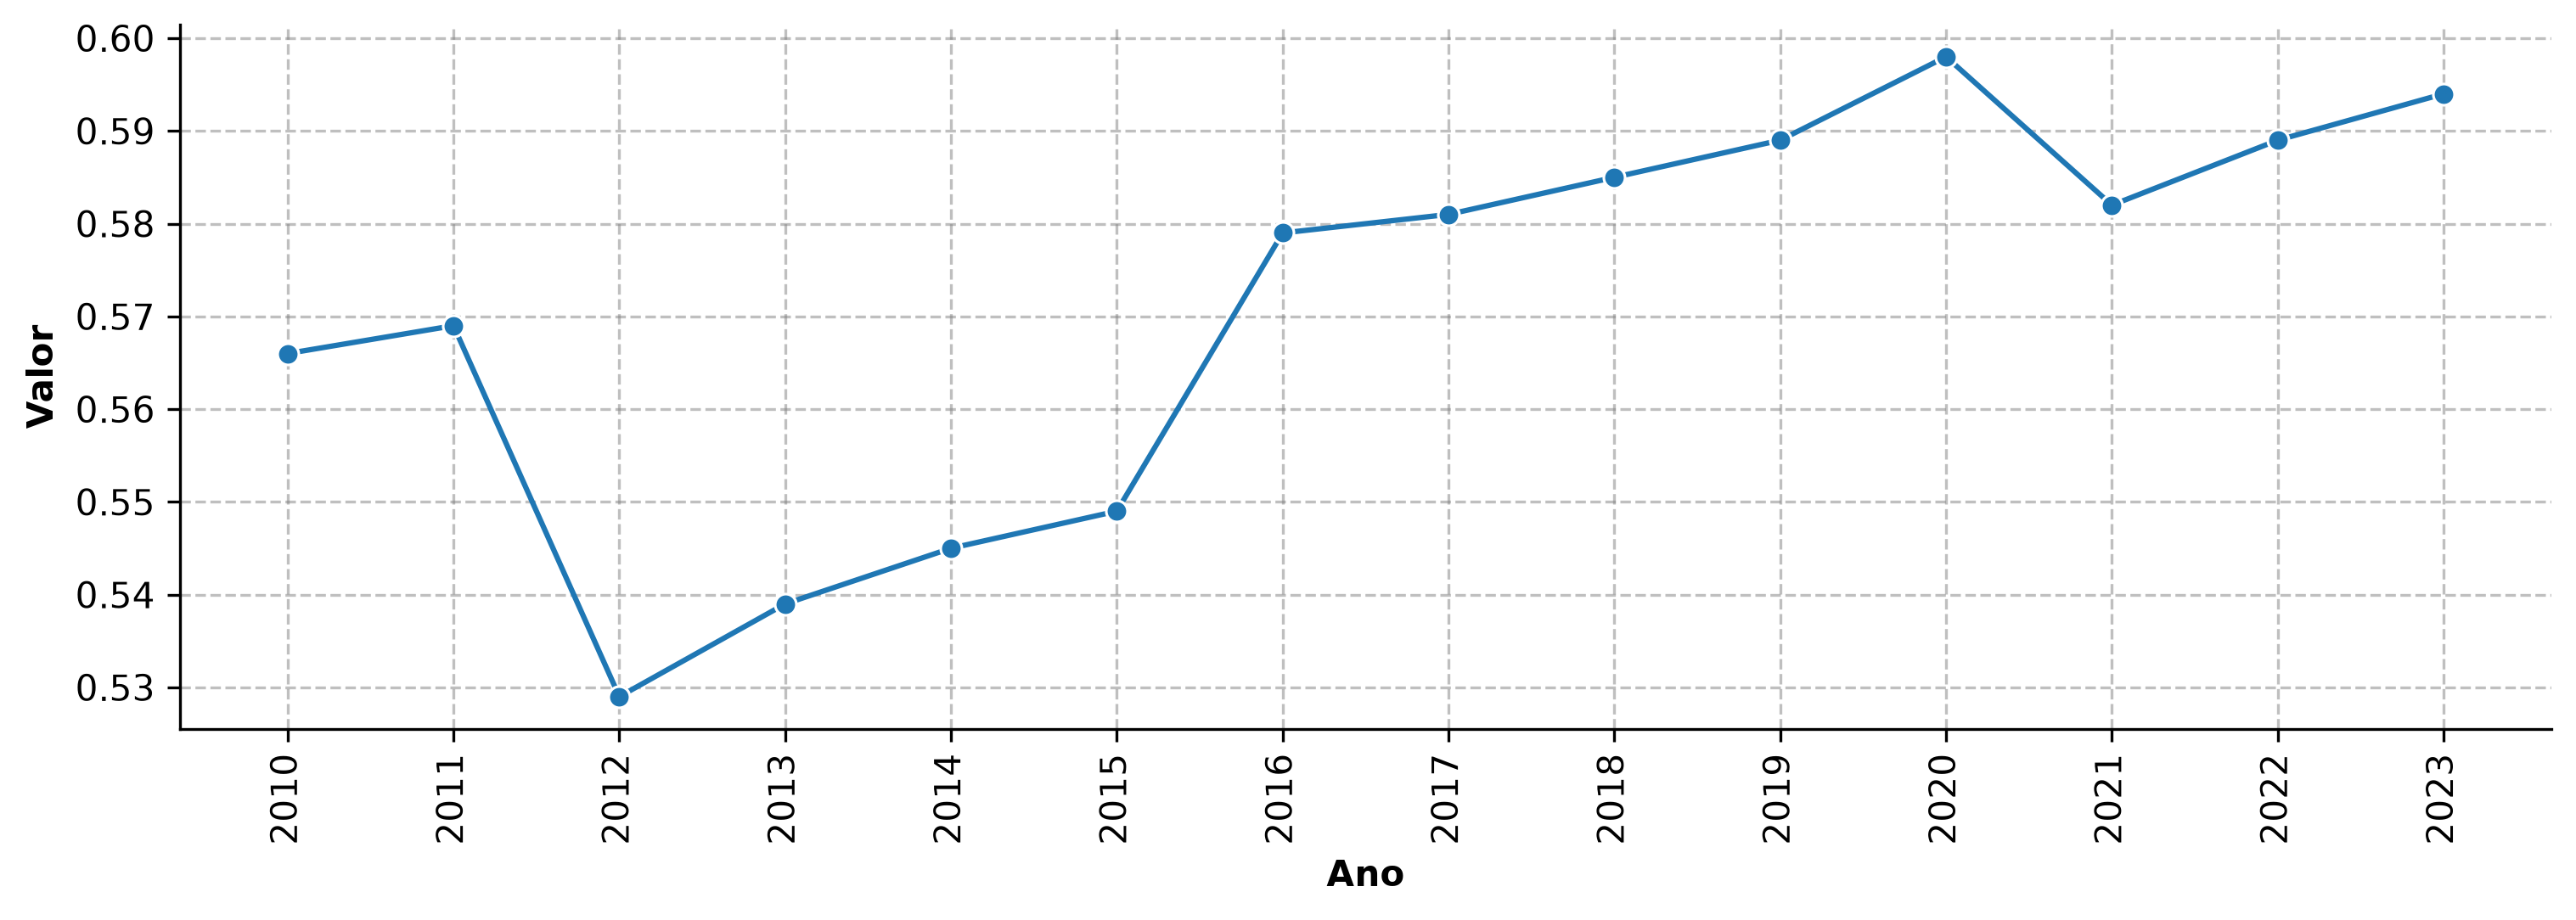

In [24]:
gerar_grafico_linha(df_ihdi, 'ihdi')